# Tech Challenge — Fase 1 | Questão 3: Análise Exploratória dos Dados (EDA)

Com o crescimento acelerado do e-commerce nacional, uma empresa passa a lidar com um volume cada vez maior de pedidos, entregas e interações com clientes. Esse crescimento trouxe ganhos importantes de escala, mas também revelou desafios relevantes na experiência do cliente, especialmente refletidos na alta variabilidade do Net Promoter Score (NPS) entre diferentes perfis de consumidores. 
A área de Experiência do Cliente percebeu que, mesmo com indicadores operacionais aparentemente semelhantes, alguns clientes se tornam promotores da marca, enquanto outros se tornam detratores. 

Este notebook analisa os dados de experiência do cliente e responde, de forma estruturada, às quatro perguntas abaixo:
1. Quais fatores parecem mais críticos para a satisfação do cliente?
2. O que mais gera detratores?
3. Existe algum *ponto de ruptura* na experiência do cliente?
4. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?


In [2]:
#LIBS Explocação
import pandas as pd
import numpy as np

#Libs Graficas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
#Definir um tamanho padrão para os gráficos  
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='darkgrid', palette='muted')

#Avisos
import warnings
warnings.filterwarnings("ignore")

## O que é o NPS

O NPS (Net Promoter Score) mede a fidelidade e satisfação do cliente a partir da pergunta: *"De 0 a 10, o quanto você indicaria nossa empresa a um amigo?"*. As respostas são divididas em três perfis:

- **Promotores (9 a 10):** clientes fiéis e entusiasmados; promovem a marca.
- **Neutros / Passivos (7 a 8):** satisfeitos, mas sem entusiasmo; vulneráveis à concorrência.
- **Detratores (0 a 6):** insatisfeitos; podem prejudicar a marca com propaganda negativa.

**NPS = % Promotores − % Detratores** (os Neutros não entram na conta), variando de −100 a +100.

## 1. Carga e visão geral da base

In [4]:
# Caminho relativo para garantir a reprodutibilidade exigida no desafio.
# Basta manter o CSV na pasta data/ (ou ajustar o caminho conforme a estrutura do repositório).
CAMINHO_CSV = '../data/raw/desafio_nps_fase_1.csv'

nps = pd.read_csv(CAMINHO_CSV)
nps.head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


In [4]:
# Dimensões da base (linhas x colunas)
nps.shape

(2500, 19)

In [5]:
# Tipos de dados de cada coluna
nps.dtypes

customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

In [6]:
# Checagem de valores nulos
qtd_nulos = nps.isnull().sum().sum()
print(f'Total de valores nulos na base: {qtd_nulos}')

Total de valores nulos na base: 0


In [7]:
# Valores únicos por coluna (ajuda a identificar IDs e variáveis categóricas)
nps.nunique()

customer_id                  2500
customer_age                   52
customer_region                 5
customer_tenure_months        119
order_id                     2500
order_value                  2457
items_quantity                  6
discount_value               2050
payment_installments           11
delivery_time_days             13
delivery_delay_days             9
freight_value                1897
delivery_attempts               3
customer_service_contacts       8
resolution_time_days           12
nps_score                     101
repeat_purchase_30d             2
complaints_count               12
csat_internal_score            98
dtype: int64

## 2. Estatística descritiva

In [8]:
# Resumo estatístico das variáveis numéricas
nps.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


### Classificação dos clientes (Detrator / Neutro / Promotor)

Criamos uma coluna de categoria a partir da nota de NPS, seguindo a régua oficial da métrica.

In [5]:
# Função que classifica cada cliente conforme a régua do NPS
def classificar_nps(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

nps['nps_categoria'] = nps['nps_score'].apply(classificar_nps)
nps[['customer_id', 'nps_score', 'nps_categoria']].head()

,customer_id,nps_score,nps_categoria
0,1,6.9,Neutro
1,2,2.4,Detrator
2,3,4.8,Detrator
3,4,5.9,Detrator
4,5,6.1,Neutro


In [6]:
# Distribuição absoluta e percentual por categoria
dist = nps['nps_categoria'].value_counts()
dist_pct = nps['nps_categoria'].value_counts(normalize=True).mul(100).round(1)

resumo_categoria = pd.DataFrame({'qtd_clientes': dist, 'percentual_%': dist_pct})
print(resumo_categoria)

# NPS oficial da base = %Promotores - %Detratores
pct_promotor = dist_pct.get('Promotor', 0)
pct_detrator = dist_pct.get('Detrator', 0)
nps_oficial = round(pct_promotor - pct_detrator)
print(f'\nNPS oficial da base: {nps_oficial}')

               qtd_clientes  percentual_%
nps_categoria                            
Detrator               1851          74.0
Neutro                  448          17.9
Promotor                201           8.0

NPS oficial da base: -66


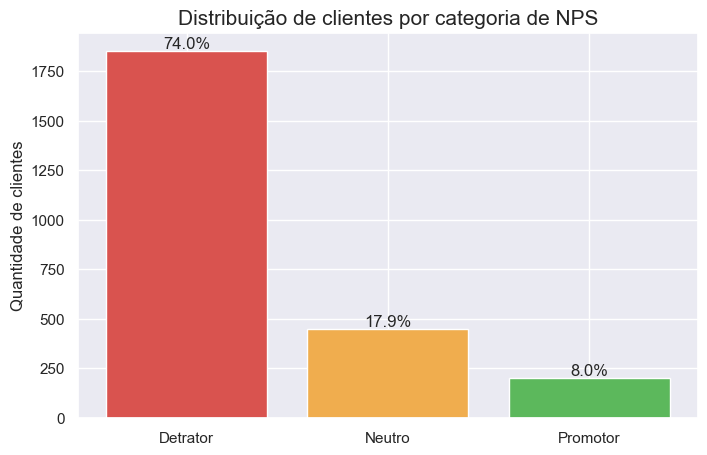

In [7]:
# Gráfico da distribuição por categoria
ordem = ['Detrator', 'Neutro', 'Promotor']
cores = {'Detrator': '#d9534f', 'Neutro': '#f0ad4e', 'Promotor': '#5cb85c'}

plt.figure(figsize=(8, 5))
plt.bar(ordem, [dist.get(c, 0) for c in ordem], color=[cores[c] for c in ordem])
plt.title('Distribuição de clientes por categoria de NPS', fontsize=15)
plt.ylabel('Quantidade de clientes')
for i, c in enumerate(ordem):
    plt.text(i, dist.get(c, 0), f'{dist_pct.get(c, 0)}%', ha='center', va='bottom', fontsize=12)
plt.show()

> A base está concentrada em **detratores**. A maior parte dos clientes saiu da jornada insatisfeita, e o NPS oficial é fortemente negativo. Ou seja, não estamos diante de um ajuste fino — há um problema estrutural na experiência que precisa ser entendido a seguir.

## 3. Quais fatores parecem mais críticos para a satisfação?

Usamos a **correlação** com a nota de NPS apenas como bússola: ela indica quais variáveis 'andam junto' com a satisfação. Valores próximos de +1 ou −1 indicam relação forte; próximos de 0, relação fraca.

In [8]:
# Correlação de cada variável numérica com a nota de NPS
corr = nps.select_dtypes(include='number').corr()

corr_com_nps = (
    corr['nps_score']
    .drop('nps_score')                      # remove a autocorrelação (sempre 1.0)
    .sort_values(key=abs, ascending=False)  # ordena pela força da relação
)

print('Correlação das variáveis com nps_score:\n')
print(corr_com_nps.round(3).to_string())

Correlação das variáveis com nps_score:

delivery_delay_days         -0.597
repeat_purchase_30d          0.570
csat_internal_score          0.564
complaints_count            -0.497
customer_service_contacts   -0.351
resolution_time_days        -0.191
freight_value               -0.041
order_value                  0.037
delivery_attempts            0.028
discount_value               0.025
payment_installments         0.024
customer_id                  0.015
order_id                     0.015
items_quantity               0.011
customer_age                -0.010
customer_tenure_months      -0.010
delivery_time_days           0.001


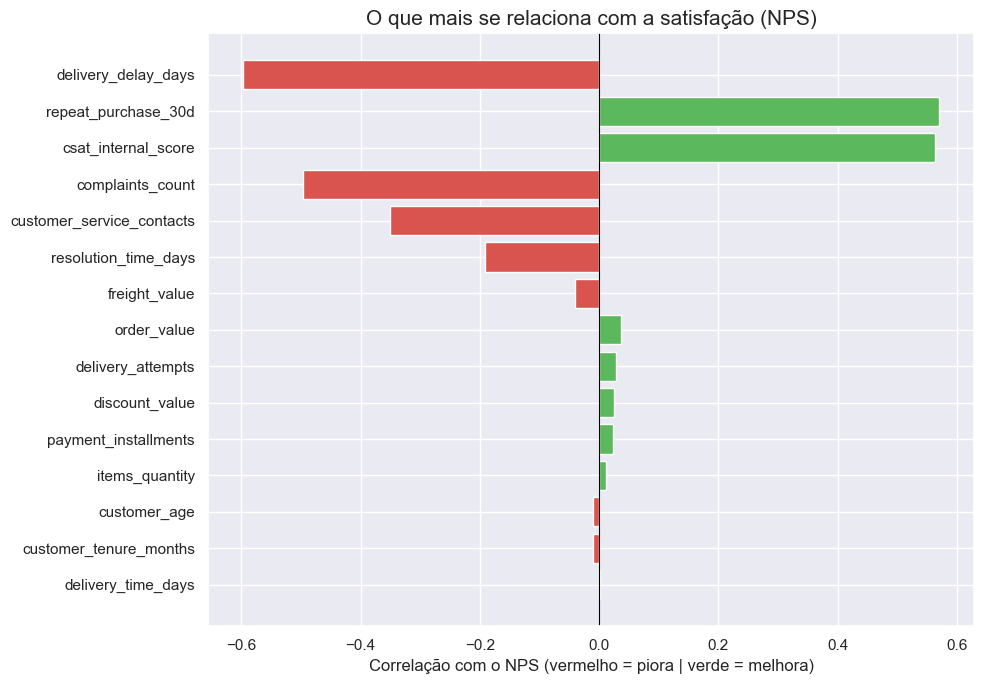

In [11]:
# Visual: ranking das relações com o NPS (ignorando IDs)
ids = ['customer_id', 'order_id']
corr_plot = corr_com_nps.drop([c for c in ids if c in corr_com_nps.index])

plt.figure(figsize=(10, 7))
cores_corr = ['#5cb85c' if v > 0 else '#d9534f' for v in corr_plot.values]
plt.barh(corr_plot.index[::-1], corr_plot.values[::-1], color=cores_corr[::-1])
plt.title('O que mais se relaciona com a satisfação (NPS)', fontsize=15)
plt.xlabel('Correlação com o NPS (vermelho = piora | verde = melhora)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

> Os fatores que mais influenciam a satisfação são todos **operacionais**, não o perfil do cliente:
>
> - **Atraso na entrega** (`delivery_delay_days`) — quanto maior o atraso, menor o NPS (relação mais forte e negativa).
> - **Score interno de satisfação** (`csat_internal_score`) — coerente com o NPS, funciona como termômetro antecipado. (Confirmar entendimento com o professor)
> - **Reclamações** e **contatos com atendimento** — quanto mais o cliente precisa acionar a empresa, pior a nota.
> - **Recompra em 30 dias** (`repeat_purchase_30d`) — quem recompra rápido tende a ser muito mais satisfeito.
>
> Variáveis como valor do pedido, frete, parcelas e quantidade de itens **quase não influenciam** a satisfação. A mensagem é direta: a satisfação se ganha (ou se perde) na **entrega e no atendimento**, não no preço ou no tamanho do pedido.

## 4. O que mais gera detratores? (e onde estão os pontos de ruptura)

A correlação aponta a direção, mas o negócio precisa enxergar **onde a experiência quebra**. Por isso, em vez de olhar só a média de NPS, medimos o **% de detratores** em cada nível dos principais drivers. Assim conseguimos identificar o **ponto de ruptura**: o momento a partir do qual a maioria dos clientes vira detrator.

### 4.1 Atraso na entrega

In [12]:
# % de detratores para cada quantidade de dias de atraso
def pct_detratores(grupo):
    return (grupo == 'Detrator').mean() * 100

atraso = (
    nps.groupby('delivery_delay_days')
    .agg(nps_medio=('nps_score', 'mean'),
         pct_detratores=('nps_categoria', pct_detratores),
         qtd_clientes=('customer_id', 'count'))
    .round(2)
    .reset_index()
)
atraso

,delivery_delay_days,nps_medio,pct_detratores,qtd_clientes
0,0,6.86,36.46,277
1,1,5.55,59.67,615
2,2,4.58,75.39,646
3,3,3.44,89.71,525
4,4,2.44,95.93,270
5,5,1.48,99.14,116
6,6,1.10,100.00,34
7,7,0.29,100.00,14
8,8,0.00,100.00,3


In [36]:
# Gráfico: % de detratores por dias de atraso
fig = px.bar(atraso, x='delivery_delay_days', y='pct_detratores',
             text='pct_detratores',
             title='% de detratores por dias de atraso na entrega',
             labels={'delivery_delay_days': 'Dias de atraso', 'pct_detratores': '% de detratores'},
             color='pct_detratores', color_continuous_scale='Reds')
fig.update_traces(texttemplate='%{text:.0f}%', textposition='outside')
fig.update_yaxes(showticklabels=False)
fig.show()

> **Ponto de ruptura na entrega:** com a entrega **no prazo**, cerca de 1 em cada 3 clientes já é detrator — sinal de que outros fatores também pesam. Mas a partir de **2 dias de atraso** a maioria já vira detratora, e a partir de **3 dias** praticamente **todo cliente** se torna detrator. O recado para a operação: **cada dia de atraso custa caro**, e o esforço de logística deveria se concentrar em não passar de 1 dia.

> **Insight:** Considerando que seja uma realidade de que em grande centros os clientes precisam se programar para estarem nos endereços de entrega, mesmo que um dia de atraso pode comprometer a programação e rotina dos clientes, o que poderia ser a real motivação destes se tornarem detratores. Como insight sugerimos possiveis parcerias para a criação de pontos de entrega/coleta.

### 4.2 Número de reclamações

In [14]:
# % de detratores por número de reclamações
# Validar a limpeza da base, olhando principalmente pelos detratores linha 10. Considerar eliminar grupos com poucos clientes
reclamacoes = (
    nps.groupby('complaints_count')
    .agg(nps_medio=('nps_score', 'mean'),
         pct_detratores=('nps_categoria', pct_detratores),
         qtd_clientes=('customer_id', 'count'))
    .round(2)
    .reset_index()
)
reclamacoes

,complaints_count,nps_medio,pct_detratores,qtd_clientes
0,0,8.52,4.35,23
1,1,7.77,8.20,122
2,2,6.05,43.32,277
3,3,4.91,67.65,507
4,4,4.22,81.17,600
5,5,3.65,88.29,444
6,6,3.06,93.61,266
7,7,2.81,93.49,169
8,8,2.07,100.00,63
9,9,2.49,100.00,16


In [35]:
fig = px.bar(reclamacoes, x='complaints_count', y='pct_detratores',
             text='pct_detratores',
             title='% de detratores por número de reclamações',
             labels={'complaints_count': 'Nº de reclamações', 'pct_detratores': '% de detratores'},
             color='pct_detratores', color_continuous_scale='Reds')
fig.update_traces(texttemplate='%{text:.0f}%', textposition='outside')
fig.update_yaxes(showticklabels=False)
fig.show()

> **Ponto de ruptura nas reclamações:** com **0 ou 1 reclamação**, quase ninguém é detrator. A virada acontece **na 2ª reclamação**: o % de detratores salta para perto da metade, e cresce rápido a partir daí. Para o negócio, isso significa que **a primeira reclamação ainda é recuperável** — mas, se o cliente precisa reclamar de novo, ele provavelmente já está perdido.

> **Insight:** Já na identificação de atraso o negócio pode considerar como um possivel impacto de NPS com um provável registro de reclamação, podendo então de forma antecipada entrar em contato com o cliente se posicionando na resolução e comprometimento com o prazo de entrega.

### 4.3 Contatos com o atendimento

In [16]:
# NPS médio e % de detratores por nº de contatos com o atendimento
# Considerar o mesmo padrão que for utilizado no 4.2
# Revisar contexto do gráfico para facilitar o entendimento.
atendimento = (
    nps.groupby('customer_service_contacts')
    .agg(nps_medio=('nps_score', 'mean'),
         pct_detratores=('nps_categoria', pct_detratores),
         qtd_clientes=('customer_id', 'count'))
    .round(2)
    .reset_index()
)
atendimento

,customer_service_contacts,nps_medio,pct_detratores,qtd_clientes
0,0,5.54,59.21,554
1,1,4.66,70.34,816
2,2,4.12,79.06,640
3,3,3.20,88.54,314
4,4,2.65,92.42,132
5,5,2.24,97.06,34
6,6,0.74,100.00,7
7,7,1.20,100.00,3


In [34]:
fig = px.bar(atendimento, x='customer_service_contacts', y='pct_detratores',
             text='pct_detratores',
             title='% de detratores por número de contatos com o atendimento',
             labels={'complaints_count': 'Nº de contatos com atendimento', 'pct_detratores': '% de detratores'},
             color='pct_detratores', color_continuous_scale='Reds')
fig.update_traces(texttemplate='%{text:.0f}%', textposition='outside')
fig.update_yaxes(showticklabels=False)
fig.show()

> **Ponto de ruptura no atendimento:** o % de detratores aumenta de forma constante a cada novo contato com o atendimento. Cada vez que o cliente precisa voltar a falar com a empresa, a satisfação despenca — o esforço de contato é, por si só, um sintoma de problema mal resolvido.

> **Insight:** Já na identificação de atraso garantir que o primeiro contato com o cliente seja realizado pela empresa demonstrando o comprometimento e empatia.

### 4.4 Tempo de resolução de problemas

In [18]:
# NPS médio por tempo de resolução
resolucao = (
    nps.groupby('resolution_time_days')
    .agg(nps_medio=('nps_score', 'mean'),
         pct_detratores=('nps_categoria', pct_detratores),
         qtd_clientes=('customer_id', 'count'))
    .round(2)
    .reset_index()
)
resolucao

,resolution_time_days,nps_medio,pct_detratores,qtd_clientes
0,0,5.32,60.10,208
1,1,5.00,64.06,192
2,2,4.82,68.12,229
3,3,4.63,70.04,237
4,4,4.44,75.24,206
5,5,4.42,75.00,176
6,6,4.32,75.63,197
7,7,4.26,76.53,213
8,8,3.97,79.74,227
9,9,4.05,79.41,204


In [30]:
fig = px.bar(resolucao, x='resolution_time_days', y='pct_detratores',
             text='pct_detratores',
             title='% de detratores por tempo de resolução de problemas (dias)',
             labels={'resolution_time_days': 'Dias para resolver', 'nps_medio': 'NPS médio'},
             color='pct_detratores', color_continuous_scale='Reds')
fig.update_traces(texttemplate='%{text:.0f}%', textposition='outside')
fig.update_yaxes(showticklabels=False)
fig.show()


> **Ponto de ruptura no atendimento:** Quanto mais tempo a empresa leva para resolver um problema, menor a satisfação. A velocidade da resolução importa: resolver rápido segura o cliente; arrastar a resolução o empurra para a detração.

> **Insight:** Manter o cliente informado das etapas seguidas para a resolução, e em conjunto enviar cupons de desconto na próxima compra tentando evitar que o cliente se torne um possivel detrator e auxiliando em uma possivel recompra. Rever os processos de resolução de problemas, mapeando de forma clara onde estão acontecendo os gargalos.

## 5. Que tipo de cliente tende a ter NPS mais alto ou mais baixo?

Aqui testamos se o **perfil do cliente** (idade, tempo de casa, região, valor do pedido) explica a satisfação — ou se ela depende mesmo só da **experiência operacional**.

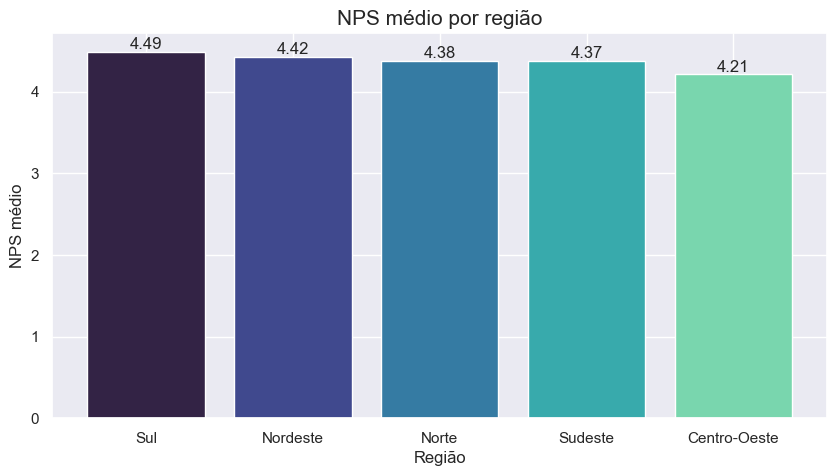

,customer_region,nps_score
0,Sul,4.49
1,Nordeste,4.42
2,Norte,4.38
3,Sudeste,4.37
4,Centro-Oeste,4.21


In [33]:
# NPS por região
nps_regiao = (
    nps.groupby('customer_region')['nps_score'].mean().round(2)
    .sort_values(ascending=False).reset_index()
)

plt.figure(figsize=(10, 5))
plt.bar(nps_regiao['customer_region'], nps_regiao['nps_score'],
        color=sns.color_palette('mako', len(nps_regiao)))
plt.title('NPS médio por região', fontsize=15)
plt.xlabel('Região'); plt.ylabel('NPS médio')
for i, v in enumerate(nps_regiao['nps_score']):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.show()
nps_regiao

In [32]:
# NPS por faixas de idade, tempo de casa e valor do pedido
perfil = nps.copy()
perfil['faixa_idade'] = pd.qcut(perfil['customer_age'], 4)
perfil['faixa_tempo_casa'] = pd.qcut(perfil['customer_tenure_months'], 4)
perfil['faixa_valor_pedido'] = pd.qcut(perfil['order_value'], 4)

for col, titulo in [('faixa_idade', 'Idade'),
                    ('faixa_tempo_casa', 'Tempo de casa (meses)'),
                    ('faixa_valor_pedido', 'Valor do pedido')]:
    print(f'\nNPS médio por {titulo}:')
    print(perfil.groupby(col)['nps_score'].mean().round(2).to_string())


NPS médio por Idade:
faixa_idade
(17.999, 31.0]    4.58
(31.0, 43.0]      4.19
(43.0, 56.0]      4.38
(56.0, 69.0]      4.36

NPS médio por Tempo de casa (meses):
faixa_tempo_casa
(0.999, 31.0]    4.41
(31.0, 62.0]     4.40
(62.0, 91.0]     4.37
(91.0, 119.0]    4.34

NPS médio por Valor do pedido:
faixa_valor_pedido
(7.7589999999999995, 220.245]    4.22
(220.245, 375.515]               4.49
(375.515, 577.29]                4.25
(577.29, 1983.81]                4.56


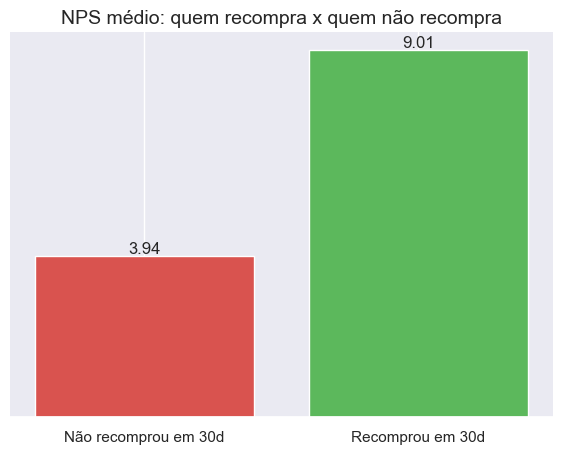

In [ ]:
# Cliente que recompra em 30 dias vs. não recompra
recompra = nps.groupby('repeat_purchase_30d')['nps_score'].mean().round(2)
recompra.index = ['Não recomprou em 30d', 'Recomprou em 30d']

plt.figure(figsize=(7, 5))
plt.bar(recompra.index, recompra.values, color=['#d9534f', '#5cb85c'])
plt.title('NPS médio: quem recompra x quem não recompra', fontsize=14)

plt.yticks([])

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

for i, v in enumerate(recompra.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12)

plt.show()

> **:** o perfil do cliente **quase não muda** a nota — idade, tempo de casa, região e valor do pedido têm NPS médio muito parecido. Não existe 'cliente difícil' por natureza. O que separa um promotor de um detrator é **a experiência que ele viveu**:
>
> - Quem **recebeu no prazo, não precisou reclamar e não acionou o atendimento** tende a ser promotor.
> - Quem **enfrentou atraso, reclamou mais de uma vez e teve resolução lenta** vira detrator — independentemente de quem seja.
>
> O cliente que **recompra em 30 dias** tem NPS muito mais alto: a recompra rápida é tanto causa quanto sinal de satisfação.

## 6. Conclusões da EDA (resumo executivo)

**Quais fatores são mais críticos para a satisfação?**
Os três pilares operacionais: **entrega no prazo**, **ausência de reclamações** e **pouco contato com o atendimento**. Preço, frete e perfil do cliente quase não pesam.

**O que mais gera detratores?**
O **atraso na entrega** é o principal vilão, seguido por **reclamações recorrentes** e **resolução lenta de problemas**. São falhas de execução, não de produto ou de público.

**Existe ponto de ruptura?**
Sim, e bem nítidos:
- **Entrega:** a partir de **2 dias de atraso** a maioria já é detratora; a partir de **3 dias**, praticamente todos.
- **Reclamações:** a **2ª reclamação** é o divisor de águas — a 1ª ainda é recuperável.
- **Atendimento:** cada novo contato derruba o NPS de forma consistente.

**Que cliente tem NPS mais alto/baixo?**
Não é uma questão de perfil. **Alto NPS** = entrega no prazo, sem reclamação, com recompra rápida. **Baixo NPS** = atraso + reclamações repetidas + atendimento lento.

**Implicação prática:** como os principais fatores são operacionais e mensuráveis *antes* da pesquisa de NPS, a empresa pode **agir preventivamente** — priorizar logística para mitigar o risco de atraso, mesmo que 1 dia, desenvolver processo de contato preventivo com o cliente mostrando comprometimento com a solução e reduzir a necessidade de recontato no atendimento.